In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# File load karein
df = pd.read_csv('retail_sales_dataset.csv')

# Data check
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Dataset Shape: (1000, 9)

Missing Values:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


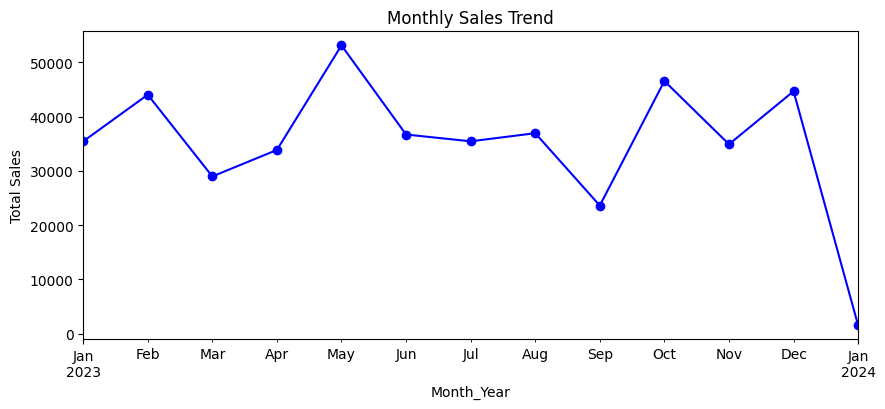

/tmp/ipykernel_2178/2641506932.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Product Category', y='Total Amount', estimator=sum, ci=None, ax=axes[1], palette='viridis')
/tmp/ipykernel_2178/2641506932.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Product Category', y='Total Amount', estimator=sum, ci=None, ax=axes[1], palette='viridis')


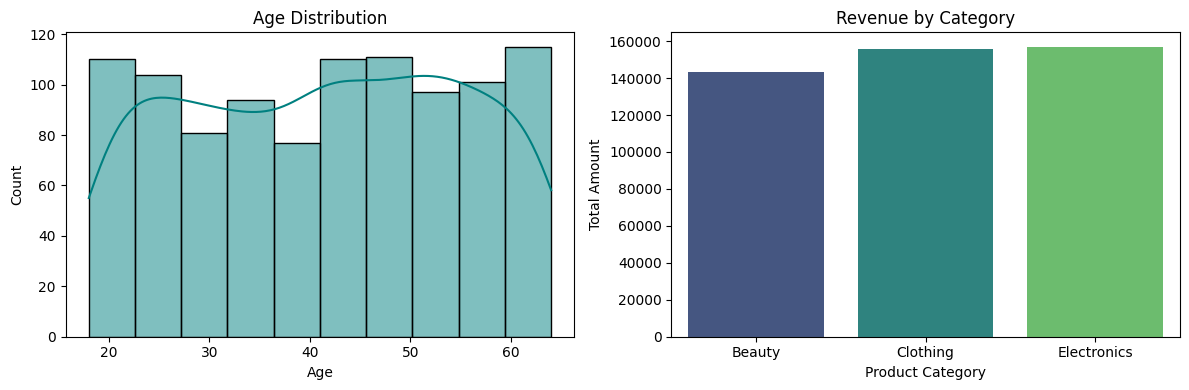

In [2]:
# Date convert aur Monthly Sales Graph
df['Date'] = pd.to_datetime(df['Date'])
df['Month_Year'] = df['Date'].dt.to_period('M')

plt.figure(figsize=(10, 4))
df.groupby('Month_Year')['Total Amount'].sum().plot(kind='line', marker='o', color='blue')
plt.title('Monthly Sales Trend')
plt.ylabel('Total Sales')
plt.show()

# Demographics & Category Charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Age'], bins=10, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Age Distribution')

sns.barplot(data=df, x='Product Category', y='Total Amount', estimator=sum, ci=None, ax=axes[1], palette='viridis')
axes[1].set_title('Revenue by Category')
plt.tight_layout()
plt.show()

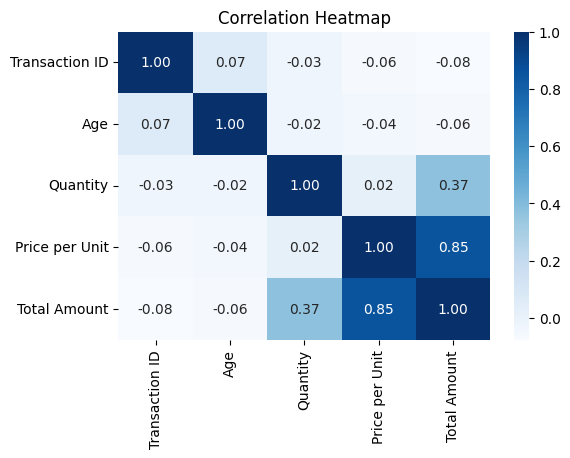

In [3]:
# Correlation Matrix
plt.figure(figsize=(6, 4))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()